In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical

In [ ]:
(x_train,y_train),(x_test,y_test) = cifar10.load_data()

print("Training Images Shape:", X_train.shape)
print("Training Labels Shape:", y_train.shape)
print("Testing Images Shape:", X_test.shape)
print("Testing Labels Shape:", y_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
Training Images Shape: (50000, 32, 32, 3)
Training Labels Shape: (50000, 1)
Testing Images Shape: (10000, 32, 32, 3)
Testing Labels Shape: (10000, 1)


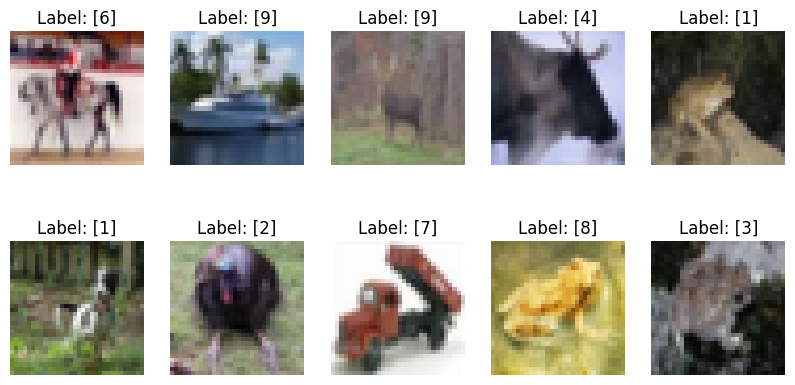

In [ ]:
plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X_train[i],cmap='gray')
    plt.title(f"Label: {y_train[i]}")
    plt.axis('off')
plt.show()

In [ ]:
X_train = X_train/255.0
X_test = X_test/255.0

In [ ]:
X_train = X_train.reshape(-1,32,32,3)
X_test = X_test.reshape(-1,32,32,3)

In [ ]:
print(X_train.shape)
print(X_test.shape)

(50000, 32, 32, 3)
(10000, 32, 32, 3)


In [ ]:
y_train =to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

In [ ]:
model = Sequential()

#First Convolution layer
model.add(Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)))
#First Pooling Layer
model.add(MaxPooling2D((2,2)))

#Second Convolution Layer
model.add(Conv2D(64, (3,3), activation='relu'))
#Second Pooling Layer
model.add(MaxPooling2D((2,2)))

#third convolution layer
model.add(Conv2D(128, (3,3), activation='relu'))
#third pooling layer
model.add(MaxPooling2D((2,2)))

#Flatten Layer
model.add(Flatten())

#Fully Connected Layer
model.add(Dense(128, activation='relu'))

#Dropout Layer
model.add(Dropout(0.5))

#Output Layer
model.add(Dense(10, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics =['accuracy'])

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 2, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 160,202 (625.79 KB)

 Trainable params: 160,202 (625.79 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(X_train, y_train, epochs=10, batch_size=32, validation_data=(X_test, y_test))

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 80s 49ms/step - accuracy: 0.4002 - loss: 1.6336 - val_accuracy: 0.5486 - val_loss: 1.2681
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 83s 50ms/step - accuracy: 0.5525 - loss: 1.2648 - val_accuracy: 0.5948 - val_loss: 1.1429
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 83s 53ms/step - accuracy: 0.6127 - loss: 1.1040 - val_accuracy: 0.6439 - val_loss: 1.0177
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 76s 49ms/step - accuracy: 0.6514 - loss: 1.0027 - val_accuracy: 0.6759 - val_loss: 0.9256
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 77s 49ms/step - accuracy: 0.6805 - loss: 0.9217 - val_accuracy: 0.6929 - val_loss: 0.8915
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 77s 49ms/step - accuracy: 0.7038 - loss: 0.8561 - val_accuracy: 0.7051 - val_loss: 0.8612
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 84s 50ms/step - accuracy: 0.7180 - loss: 0.8080 - val_accuracy: 0.6935 - val_loss: 0.8895
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 78s 48ms/step - accuracy: 0.7353 -

In [ ]:
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.7054 - loss: 0.8682
Test Loss: 0.8681752681732178
Test Accuracy: 0.7053999900817871


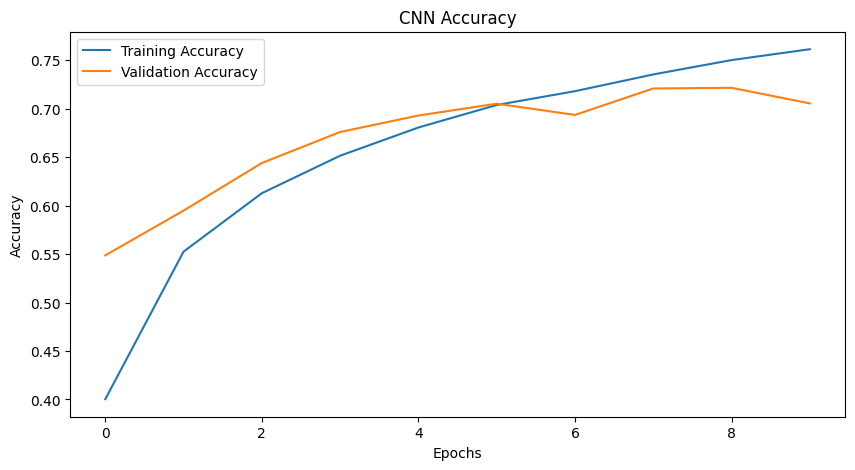

In [ ]:
#Accuracy Curve
plt.figure(figsize=(10,5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('CNN Accuracy')
plt.legend()
plt.show()

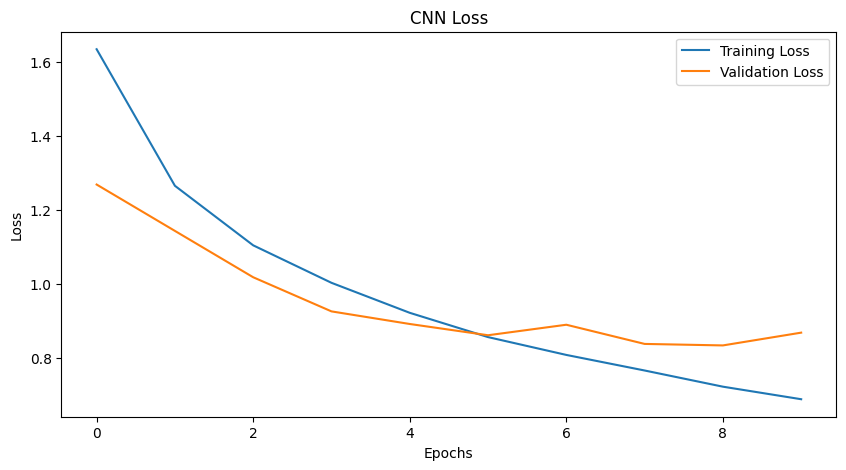

In [ ]:
#Loss Curve
plt.figure(figsize=(10,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('CNN Loss')
plt.legend()

In [ ]:
class_names=['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


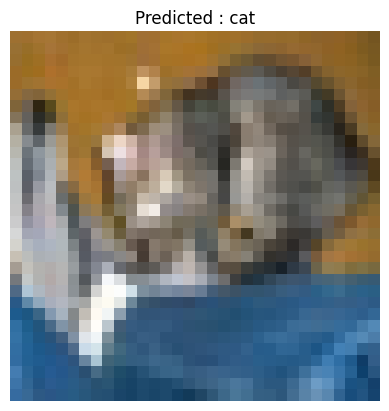

In [ ]:
sample = X_test[0]
prediction = model.predict(sample.reshape(1,32,32,3))
predicted_class = np.argmax(prediction)
predicted_class_name = class_names[predicted_class]
plt.imshow(sample)
plt.title(f"Predicted : {predicted_class_name}")
plt.axis('off')
plt.show()

Saving Screenshot 2026-06-04 113618.png to Screenshot 2026-06-04 113618 (6).png


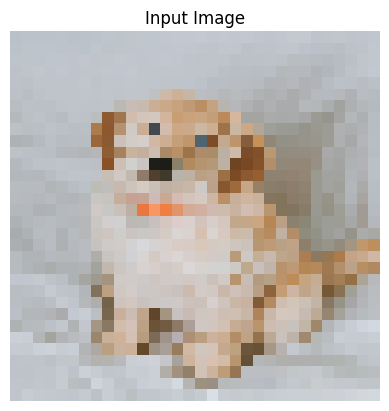

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
Predicted : dog
Confidence Score: 60.069202 %


In [ ]:
from google.colab import files
from tensorflow.keras.preprocessing import image
import cv2

uploaded = files.upload()
img_path = list(uploaded.keys())[0]

# Read as color image
img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Resize the image
img = cv2.resize(img, (32,32))

# Normalize the image
img = img/255.0

# Display Image
plt.imshow(img)
plt.title("Input Image")
plt.axis('off')
plt.show()

# Reshape
img = img.reshape(1,32,32,3)

# Predict the image
prediction = model.predict(img)
predicted_class = np.argmax(prediction)
predicted_class_name = class_names[predicted_class]
print(f"Predicted : {predicted_class_name}")

# Print the confidence score
print("Confidence Score:",np.max(prediction)*100,"%")